# 🔎 Análisis Exploratorio de Datos (EDA)

**Módulo 2** | **Sesión 3** | **Duración estimada: 1h 30min**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gonzalezulises/formacion-docente-bi-faces/blob/main/modulo-02-data-wrangling/notebooks/02_01_eda_exploratorio.ipynb)

---

En esta sesión aprenderemos a **explorar sistemáticamente un conjunto de datos** antes de realizar cualquier análisis o modelo. El Análisis Exploratorio de Datos (EDA) es el primer paso obligatorio en todo proyecto de ciencia de datos: conocer la estructura, detectar anomalías, identificar patrones y formular hipótesis.

## 🎯 Objetivos de Aprendizaje

| # | Competencia                                             | Nivel         | Indicador de logro                                                  |
|---|---------------------------------------------------------|---------------|---------------------------------------------------------------------|
| 1 | Comprender el propósito y la metodología del EDA        | Conceptual    | Explica por qué el EDA precede a cualquier modelado                 |
| 2 | Calcular e interpretar estadísticas descriptivas         | Procedimental | Usa `.describe()` y funciones estadísticas sobre DataFrames         |
| 3 | Visualizar distribuciones e identificar formas          | Procedimental | Crea histogramas y gráficos KDE para variables numéricas            |
| 4 | Detectar y tratar valores faltantes                     | Procedimental | Identifica missings y aplica estrategias de tratamiento            |
| 5 | Identificar outliers usando métodos estadísticos        | Procedimental | Aplica boxplots y el método IQR para detectar valores atípicos      |
| 6 | Analizar correlaciones entre variables                  | Aplicado      | Interpreta matrices de correlación en contextos académicos         |
| 7 | Realizar un EDA completo de principio a fin             | Aplicado      | Ejecuta un flujo EDA sistemático sobre datos reales                 |

## 💡 ¿Por qué es importante para tu práctica docente?

Como docente de FACES, constantemente trabajas con datos que podrías analizar de forma más sistemática: calificaciones de tus estudiantes, resultados de encuestas, indicadores de gestión académica. El EDA te permite:

- 🏫 **Diagnóstico estudiantil:** Explorar el rendimiento de tus grupos para identificar patrones (p.ej., ¿los estudiantes que trabajan tienen menor promedio?)
- 📊 **Calidad de datos:** Detectar datos faltantes o erróneos antes de sacar conclusiones. Un solo valor atípico puede distorsionar un promedio
- 🔍 **Formulación de hipótesis:** El EDA no busca confirmar hipótesis, sino generarlas. Es la fase de descubrimiento
- 📝 **Investigación académica:** Todo artículo científico incluye una sección de análisis descriptivo. El EDA es esa sección

> 📣 **John Tukey**, padre del EDA, decía: *"El análisis exploratorio de datos es una actitud, un estado de flexibilidad, una disposición a buscar aquellas cosas que creemos que no están ahí, así como las que creemos que sí están."*

---

## ⚙️ Configuración inicial

Importamos las bibliotecas necesarias y cargamos nuestro dataset principal.

In [1]:
# ============================================================
# Configuración inicial: bibliotecas
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_palette('Set2')
warnings.filterwarnings('ignore')

# Para mostrar todas las columnas en DataFrames
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print('✅ Bibliotecas cargadas exitosamente')
print(f'   pandas {pd.__version__}')
print(f'   numpy {np.__version__}')

✅ Bibliotecas cargadas exitosamente
   pandas 2.2.2
   numpy 2.0.2


In [3]:
# ============================================================
# Cargar el dataset principal: rendimiento académico
# ============================================================

df = pd.read_csv('https://raw.githubusercontent.com/gonzalezulises/formacion-docente-bi-faces/refs/heads/main/datasets/universidad/rendimiento_academico.csv')

print(f'✅ Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'\n📝 Columnas: {list(df.columns)}')
print(f'\n👀 Primeras 5 filas:')
df.head()

✅ Dataset cargado: 3,000 filas x 12 columnas

📝 Columnas: ['estudiante_id', 'carrera', 'semestre', 'genero', 'edad', 'promedio', 'materias_inscritas', 'materias_aprobadas', 'materias_reprobadas', 'asistencia_pct', 'beca', 'trabaja']

👀 Primeras 5 filas:


,estudiante_id,carrera,semestre,genero,edad,promedio,materias_inscritas,materias_aprobadas,materias_reprobadas,asistencia_pct,beca,trabaja
0,EST-0001,Contaduria,1,M,19,6.0,5,0,5,69.6,False,True
1,EST-0002,Administracion,6,F,23,10.1,4,1,3,77.4,False,True
2,EST-0003,Contaduria,4,M,21,19.8,4,4,0,100.0,False,False
3,EST-0004,Contaduria,5,F,25,16.3,4,3,1,61.6,False,False
4,EST-0005,Economia,8,F,20,12.4,7,4,3,79.9,False,False


---

## 🔎 Sección 1: ¿Qué es EDA?

El **Análisis Exploratorio de Datos** (Exploratory Data Analysis, EDA) es un enfoque sistemático para investigar datasets utilizando estadísticas descriptivas y visualizaciones. Fue formalizado por **John Tukey** en 1977.

### La analogía del detective

Imagina que eres un **detective** que llega a la escena de un caso:

1. **Observar la escena** → Ver la estructura de los datos (`shape`, `dtypes`, `head`)
2. **Recoger evidencia** → Calcular estadísticas descriptivas (`describe`, `value_counts`)
3. **Buscar pistas** → Visualizar distribuciones y relaciones (histogramas, scatter plots)
4. **Identificar sospechosos** → Detectar anomalías, outliers, valores faltantes
5. **Formular hipótesis** → Proponer explicaciones basadas en los patrones encontrados

### El flujo de un EDA

| Paso | Acción | Preguntas clave |
|------|--------|----------------|
| 1 | Estructura | ¿Cuántas filas/columnas? ¿Qué tipos de datos? |
| 2 | Estadísticas | ¿Cuál es la media, mediana, rango? |
| 3 | Distribuciones | ¿Cómo se distribuyen las variables? ¿Son normales? |
| 4 | Valores faltantes | ¿Hay datos incompletos? ¿Dónde? |
| 5 | Outliers | ¿Hay valores extremos? ¿Son errores o datos reales? |
| 6 | Correlaciones | ¿Qué variables están relacionadas entre sí? |
| 7 | Conclusiones | ¿Qué patrones encontramos? ¿Qué hipótesis podemos formular? |

---

## 📊 Sección 2: Estadísticas descriptivas

Las estadísticas descriptivas resumen las características principales de un conjunto de datos. Son la **primera mirada numérica** a nuestros datos.

### Medidas clave

| Medida | Descripción | Función pandas |
|--------|-----------|---------------|
| **Media** | Promedio aritmético | `.mean()` |
| **Mediana** | Valor central (50º percentil) | `.median()` |
| **Moda** | Valor más frecuente | `.mode()` |
| **Desviación estándar** | Dispersión respecto a la media | `.std()` |
| **Mínimo / Máximo** | Rango de valores | `.min()`, `.max()` |
| **Cuartiles** | Dividen los datos en 4 partes iguales | `.quantile()` |

In [4]:
# ============================================================
# El método .describe() — resumen estadístico completo
# ============================================================

print('📊 Estadísticas descriptivas de todas las variables numéricas:')
print('=' * 70)
df.describe().round(2)

📊 Estadísticas descriptivas de todas las variables numéricas:


,semestre,edad,promedio,materias_inscritas,materias_aprobadas,materias_reprobadas,asistencia_pct
count,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00,3000.00
mean,5.61,22.32,13.32,5.51,3.66,1.86,80.58
std,2.88,2.83,2.58,1.11,1.52,1.38,12.02
min,1.00,17.00,5.00,4.00,0.00,0.00,31.40
25%,3.00,20.00,11.50,5.00,3.00,1.00,72.80
50%,6.00,22.00,13.40,6.00,4.00,2.00,80.70
75%,8.00,24.00,15.10,6.00,5.00,3.00,89.40
max,10.00,32.00,20.00,7.00,7.00,7.00,100.00


In [5]:
# ============================================================
# Interpretación de .describe() para la columna 'promedio'
# ============================================================

stats = df['promedio'].describe()

print('🎯 Interpretación del promedio académico:')
print('=' * 50)
print(f'  Estudiantes analizados: {stats["count"]:.0f}')
print(f'  Promedio general:       {stats["mean"]:.2f} (de 20 puntos)')
print(f'  Desviación estándar:    {stats["std"]:.2f}')
print(f'  Nota mínima:            {stats["min"]:.1f}')
print(f'  Cuartil 1 (25%):        {stats["25%"]:.2f}  ← 25% tiene menos que esto')
print(f'  Mediana (50%):          {stats["50%"]:.2f}  ← valor central')
print(f'  Cuartil 3 (75%):        {stats["75%"]:.2f}  ← 75% tiene menos que esto')
print(f'  Nota máxima:            {stats["max"]:.1f}')
print()
print(f'  📌 La mediana ({stats["50%"]:.2f}) vs la media ({stats["mean"]:.2f}):')
if abs(stats['mean'] - stats['50%']) < 0.5:
    print('     Son muy cercanas → la distribución es aproximadamente simétrica')
elif stats['mean'] > stats['50%']:
    print('     La media > mediana → sesgo hacia la derecha (cola de notas altas)')
else:
    print('     La media < mediana → sesgo hacia la izquierda (cola de notas bajas)')

🎯 Interpretación del promedio académico:
  Estudiantes analizados: 3000
  Promedio general:       13.32 (de 20 puntos)
  Desviación estándar:    2.58
  Nota mínima:            5.0
  Cuartil 1 (25%):        11.50  ← 25% tiene menos que esto
  Mediana (50%):          13.40  ← valor central
  Cuartil 3 (75%):        15.10  ← 75% tiene menos que esto
  Nota máxima:            20.0

  📌 La mediana (13.40) vs la media (13.32):
     Son muy cercanas → la distribución es aproximadamente simétrica


In [6]:
# ============================================================
# Estadísticas por carrera (agrupadas)
# ============================================================

print('🏫 Promedio académico por carrera:')
print('=' * 60)

resumen_carrera = df.groupby('carrera')['promedio'].agg(
    ['count', 'mean', 'median', 'std', 'min', 'max']
).round(2)
resumen_carrera.columns = ['N', 'Media', 'Mediana', 'Desv.Est.', 'Mín', 'Máx']

print(resumen_carrera)
print()
print('📌 Observa: ¿Qué carrera tiene mayor variabilidad (desviación estándar)?')
print(f'   Mayor variabilidad: {resumen_carrera["Desv.Est."].idxmax()}')

🏫 Promedio académico por carrera:
                           N  Media  Mediana  Desv.Est.  Mín   Máx
carrera                                                           
Administracion           915  13.42     13.5       2.55  7.1  20.0
Contaduria               720  13.37     13.4       2.63  5.0  20.0
Economia                 756  13.30     13.3       2.57  5.3  20.0
Relaciones Industriales  609  13.15     13.3       2.57  5.0  20.0

📌 Observa: ¿Qué carrera tiene mayor variabilidad (desviación estándar)?
   Mayor variabilidad: Contaduria


---

## 📈 Sección 3: Distribuciones

Una **distribución** muestra cómo se reparten los valores de una variable. Es como responder: *¿dónde se concentra la mayoría de los datos?*

### Herramientas de visualización

- **Histograma:** Divide los datos en intervalos (bins) y cuenta cuántos caen en cada uno
- **KDE (Kernel Density Estimation):** Una curva suavizada que estima la distribución
- **Formas comunes:** Normal (campana), sesgada a la derecha, sesgada a la izquierda, bimodal

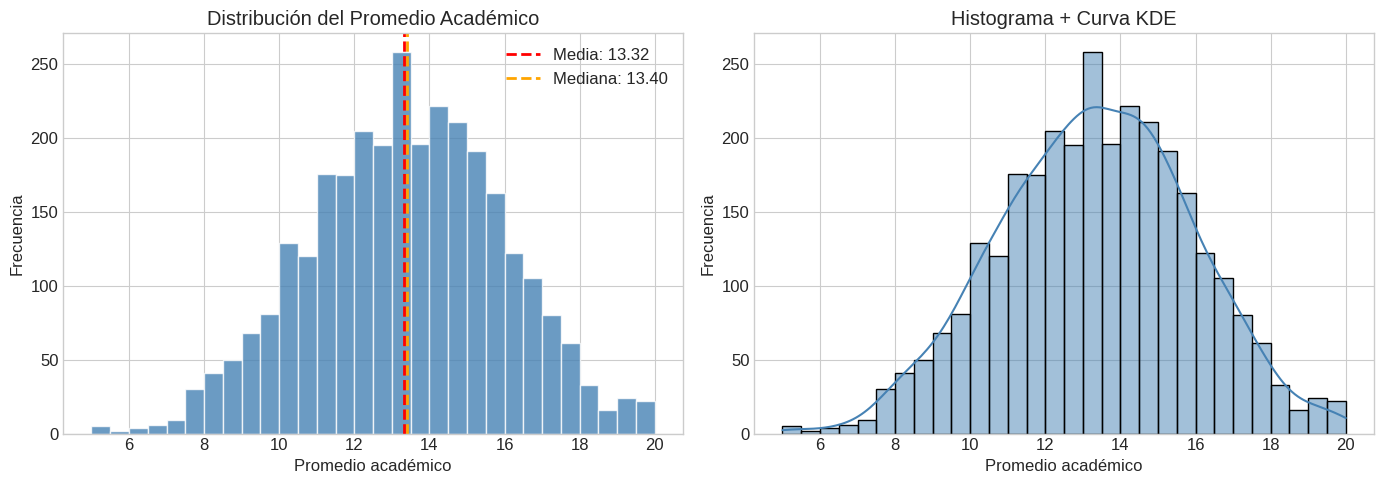


📌 Interpretación:
   - La línea roja (media) y naranja (mediana) indican la tendencia central
   - Si ambas líneas están cerca, la distribución es simétrica
   - La curva KDE suaviza el histograma para ver mejor la forma general


In [7]:
# ============================================================
# Histograma + KDE de la variable 'promedio'
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma básico
axes[0].hist(df['promedio'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df['promedio'].mean(), color='red', linestyle='--', linewidth=2, label=f'Media: {df["promedio"].mean():.2f}')
axes[0].axvline(df['promedio'].median(), color='orange', linestyle='--', linewidth=2, label=f'Mediana: {df["promedio"].median():.2f}')
axes[0].set_xlabel('Promedio académico')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución del Promedio Académico')
axes[0].legend()

# Histograma + KDE con seaborn
sns.histplot(df['promedio'], bins=30, kde=True, color='steelblue', ax=axes[1])
axes[1].set_xlabel('Promedio académico')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Histograma + Curva KDE')

plt.tight_layout()
plt.show()

print('\n📌 Interpretación:')
print('   - La línea roja (media) y naranja (mediana) indican la tendencia central')
print('   - Si ambas líneas están cerca, la distribución es simétrica')
print('   - La curva KDE suaviza el histograma para ver mejor la forma general')

In [ ]:
# ============================================================
# Distribución del promedio por carrera (comparación)
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
carreras = df['carrera'].unique()
colores = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

for i, (carrera, color) in enumerate(zip(carreras, colores)):
    ax = axes[i // 2, i % 2]
    datos_carrera = df[df['carrera'] == carrera]['promedio']
    sns.histplot(datos_carrera, bins=25, kde=True, color=color, ax=ax)
    ax.axvline(datos_carrera.mean(), color='red', linestyle='--', linewidth=1.5)
    ax.set_title(f'{carrera} (n={len(datos_carrera)}, media={datos_carrera.mean():.2f})')
    ax.set_xlabel('Promedio')
    ax.set_ylabel('Frecuencia')

plt.suptitle('Distribución del Promedio por Carrera', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n📌 ¿Todas las carreras tienen distribuciones similares?')
print('   Compara la forma, la dispersión y la posición de la media (línea roja)')

---

## ❓ Sección 4: Valores faltantes

Los **valores faltantes** (missing values, NaN) son uno de los problemas más comunes en datos reales. Pueden deberse a:

- **Errores de registro:** El encuestador no anotó un dato
- **No aplica:** Un estudiante no tiene beca, así que el campo de monto está vacío
- **Pérdida de datos:** Un sistema falló y no guardó ciertos registros

### Estrategias de tratamiento

| Estrategia | Cuándo usar | Función pandas |
|-----------|------------|---------------|
| **Eliminar filas** | Pocos faltantes (<5%) | `df.dropna()` |
| **Rellenar con media** | Variable numérica, distribución simétrica | `df.fillna(df.mean())` |
| **Rellenar con mediana** | Variable numérica, con outliers | `df.fillna(df.median())` |
| **Rellenar con moda** | Variable categórica | `df.fillna(df.mode()[0])` |
| **Imputación avanzada** | Muchos faltantes, patrones complejos | scikit-learn `SimpleImputer` |

In [ ]:
# ============================================================
# Detección de valores faltantes
# ============================================================

print('❓ Valores faltantes por columna:')
print('=' * 40)

faltantes = df.isnull().sum()
pct_faltantes = (df.isnull().sum() / len(df) * 100).round(2)

resumen_faltantes = pd.DataFrame({
    'Faltantes': faltantes,
    'Porcentaje (%)': pct_faltantes
})

print(resumen_faltantes)
print(f'\nTotal de celdas faltantes: {faltantes.sum()}')
print(f'Porcentaje total: {(faltantes.sum() / df.size * 100):.2f}%')

if faltantes.sum() == 0:
    print('\n✅ Este dataset no tiene valores faltantes. ¡Excelente!')
    print('   En la práctica, esto es raro. Veamos cómo simular y manejar faltantes.')

In [ ]:
# ============================================================
# Simulación y visualización de valores faltantes
# ============================================================
# Para fines didácticos, crearemos una copia con faltantes aleatorios

np.random.seed(42)
df_con_faltantes = df.copy()

# Introducir faltantes aleatorios en algunas columnas
for col in ['promedio', 'asistencia_pct', 'materias_aprobadas']:
    mask = np.random.random(len(df_con_faltantes)) < 0.05  # 5% de faltantes
    df_con_faltantes.loc[mask, col] = np.nan

print('📊 Faltantes simulados:')
print(df_con_faltantes.isnull().sum())
print()

# Visualizar patrón de faltantes con heatmap
fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(df_con_faltantes.isnull().T, cmap='YlOrRd', cbar_kws={'label': 'Faltante'},
            yticklabels=True, ax=ax)
ax.set_title('Mapa de Valores Faltantes (amarillo = presente, rojo = faltante)')
ax.set_xlabel('Observaciones')
plt.tight_layout()
plt.show()

print('\n📌 Este mapa permite ver si los faltantes siguen un patrón')
print('   (ej: si una misma fila tiene faltantes en varias columnas)')

In [ ]:
# ============================================================
# Tratamiento de valores faltantes: ejemplo práctico
# ============================================================

print('Antes del tratamiento:')
print(df_con_faltantes[['promedio', 'asistencia_pct', 'materias_aprobadas']].isnull().sum())
print()

# Estrategia: rellenar con la mediana (robusta ante outliers)
df_imputado = df_con_faltantes.copy()
for col in ['promedio', 'asistencia_pct', 'materias_aprobadas']:
    mediana = df_imputado[col].median()
    df_imputado[col].fillna(mediana, inplace=True)
    print(f'  {col}: faltantes rellenados con mediana = {mediana:.2f}')

print(f'\nDespués del tratamiento:')
print(df_imputado[['promedio', 'asistencia_pct', 'materias_aprobadas']].isnull().sum())
print('\n✅ Todos los faltantes han sido tratados')

---

## 📍 Sección 5: Outliers (valores atípicos)

Un **outlier** es un valor que se aleja significativamente del resto de los datos. Puede ser:

- **Un error:** Una nota de 200 cuando la escala es de 0-20
- **Un dato real pero extremo:** Un estudiante con promedio 20 perfecto
- **Un indicador importante:** Un departamento con gasto extremadamente alto

### Método IQR (Rango Intercuartílico)

Es el método más común para detectar outliers:

1. Calcular Q1 (percentil 25) y Q3 (percentil 75)
2. IQR = Q3 - Q1
3. Límite inferior = Q1 - 1.5 * IQR
4. Límite superior = Q3 + 1.5 * IQR
5. Todo valor fuera de estos límites es un outlier

In [ ]:
# ============================================================
# Boxplot de promedio por carrera
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df, x='carrera', y='promedio', palette='Set2', ax=ax)
ax.set_title('Distribución del Promedio por Carrera (Boxplot)', fontsize=14)
ax.set_xlabel('Carrera')
ax.set_ylabel('Promedio (escala 0-20)')

# Añadir línea de promedio general
ax.axhline(df['promedio'].mean(), color='red', linestyle='--', alpha=0.5,
           label=f'Promedio general: {df["promedio"].mean():.2f}')
ax.legend()

plt.tight_layout()
plt.show()

print('\n📌 Cómo leer un boxplot:')
print('   - La caja contiene el 50% central de los datos (Q1 a Q3)')
print('   - La línea dentro de la caja es la mediana')
print('   - Los bigotes se extienden hasta 1.5 * IQR')
print('   - Los puntos fuera de los bigotes son outliers')

In [ ]:
# ============================================================
# Identificar outliers con el método IQR (manual)
# ============================================================

Q1 = df['promedio'].quantile(0.25)
Q3 = df['promedio'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f'📊 Análisis de outliers en "promedio":')
print(f'   Q1 = {Q1:.2f}')
print(f'   Q3 = {Q3:.2f}')
print(f'   IQR = {IQR:.2f}')
print(f'   Límite inferior = {limite_inferior:.2f}')
print(f'   Límite superior = {limite_superior:.2f}')
print()

# Identificar outliers
outliers = df[(df['promedio'] < limite_inferior) | (df['promedio'] > limite_superior)]
print(f'⚠️ Se detectaron {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}% de los datos)')

if len(outliers) > 0:
    print(f'\n   Outliers por debajo ({limite_inferior:.2f}):')
    print(f'   {len(df[df["promedio"] < limite_inferior])} estudiantes')
    print(f'\n   Outliers por encima ({limite_superior:.2f}):')
    print(f'   {len(df[df["promedio"] > limite_superior])} estudiantes')
else:
    print('\n✅ No se detectaron outliers con el método IQR')
    print('   Esto puede significar que los datos son bastante homogéneos')

---

## 🔗 Sección 6: Correlaciones

La **correlación** mide la fuerza y dirección de la relación lineal entre dos variables numéricas.

| Valor | Interpretación |
|-------|---------------|
| +1.0 | Correlación positiva perfecta |
| +0.7 a +1.0 | Correlación positiva fuerte |
| +0.3 a +0.7 | Correlación positiva moderada |
| -0.3 a +0.3 | Correlación débil o nula |
| -0.7 a -0.3 | Correlación negativa moderada |
| -1.0 a -0.7 | Correlación negativa fuerte |
| -1.0 | Correlación negativa perfecta |

> **⚠️ Recordatorio importante:** Correlación no implica causalidad. Que dos variables estén correlacionadas no significa que una cause la otra.

In [ ]:
# ============================================================
# Matriz de correlación
# ============================================================

# Seleccionar solo columnas numéricas
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Variables numéricas: {cols_numericas}')

# Calcular correlaciones
correlaciones = df[cols_numericas].corr().round(3)

print('\n🔗 Matriz de correlación:')
print(correlaciones)

In [ ]:
# ============================================================
# Heatmap de correlaciones
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

# Crear máscara para el triángulo superior (evitar duplicados)
mask = np.triu(np.ones_like(correlaciones, dtype=bool))

sns.heatmap(correlaciones, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Coeficiente de correlación'})

ax.set_title('Matriz de Correlación — Rendimiento Académico FACES', fontsize=14)
plt.tight_layout()
plt.show()

# Encontrar las correlaciones más fuertes con 'promedio'
print('\n🎯 Correlaciones con "promedio" (ordenadas por fuerza):')
corr_promedio = correlaciones['promedio'].drop('promedio').abs().sort_values(ascending=False)
for variable, valor in corr_promedio.items():
    signo = '+' if correlaciones.loc[variable, 'promedio'] > 0 else '-'
    print(f'   {variable:25s} {signo}{valor:.3f}')

---

## 📊 Sección 7: Tablas cruzadas y frecuencias

Las **tablas cruzadas** (crosstabs) son el equivalente a las tablas dinámicas de Excel. Permiten analizar la relación entre dos variables categóricas.

- `pd.crosstab()` — Tabla cruzada de frecuencias
- `value_counts()` — Conteo de frecuencias de una variable
- `normalize=True` — Mostrar proporciones en lugar de conteos

In [ ]:
# ============================================================
# Tabla cruzada: carrera x género
# ============================================================

print('📊 Tabla cruzada: Carrera x Género (conteos)')
print('=' * 45)
ct = pd.crosstab(df['carrera'], df['genero'], margins=True, margins_name='Total')
print(ct)

print('\n📊 Tabla cruzada: Carrera x Género (porcentajes por fila)')
print('=' * 55)
ct_pct = pd.crosstab(df['carrera'], df['genero'], normalize='index').round(3) * 100
ct_pct.columns = ['% Femenino', '% Masculino']
print(ct_pct)

print('\n📌 ¿Hay diferencias de género en la composición de las carreras?')

In [ ]:
# ============================================================
# Tabla cruzada: carrera x beca
# ============================================================

print('📊 Tabla cruzada: Carrera x Beca (porcentajes)')
print('=' * 50)
ct_beca = pd.crosstab(df['carrera'], df['beca'], normalize='index').round(3) * 100
ct_beca.columns = ['Sin Beca (%)', 'Con Beca (%)']
print(ct_beca)

print('\n📊 Frecuencias de la variable "trabaja":')
print(df['trabaja'].value_counts(normalize=True).round(3) * 100)

print('\n📌 ¿Qué porcentaje de estudiantes combina estudios con trabajo?')

---

## 🛠️ Sección 8: EDA completo — Caso práctico

Ahora vamos a realizar un **EDA completo y sistemático** sobre nuestro dataset de rendimiento académico. Seguiremos el flujo de 7 pasos que definimos al inicio.

In [ ]:
# ============================================================
# PASO 1: Estructura del dataset
# ============================================================

print('🔎 PASO 1: Estructura del dataset')
print('=' * 50)
print(f'Dimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas')
print(f'Uso de memoria: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
print('Tipos de datos:')
print(df.dtypes)
print()
print('Primeras filas:')
df.head(3)

In [ ]:
# ============================================================
# PASO 2: Estadísticas descriptivas
# ============================================================

print('📊 PASO 2: Estadísticas descriptivas')
print('=' * 50)
print('\nVariables numéricas:')
print(df.describe().round(2).to_string())
print('\nVariables categóricas:')
for col in df.select_dtypes(include='object').columns:
    print(f'\n  {col}:')
    print(f'  {df[col].value_counts().to_dict()}')

In [ ]:
# ============================================================
# PASO 3: Valores faltantes
# ============================================================

print('❓ PASO 3: Valores faltantes')
print('=' * 50)
faltantes = df.isnull().sum()
if faltantes.sum() == 0:
    print('✅ No hay valores faltantes en el dataset')
else:
    print(faltantes[faltantes > 0])

In [ ]:
# ============================================================
# PASO 4 & 5: Distribuciones y outliers
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Variables a visualizar
variables = ['promedio', 'asistencia_pct', 'edad',
             'materias_inscritas', 'materias_aprobadas', 'materias_reprobadas']

for i, var in enumerate(variables):
    ax = axes[i // 3, i % 3]
    sns.boxplot(data=df, y=var, color='steelblue', ax=ax)
    ax.set_title(f'Boxplot: {var}')

plt.suptitle('PASO 4 & 5: Distribuciones y Outliers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PASO 6: Correlaciones
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))
correlaciones = df.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(correlaciones, dtype=bool))
sns.heatmap(correlaciones, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('PASO 6: Correlaciones entre Variables', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PASO 7: Resumen de hallazgos
# ============================================================

print('🎯 PASO 7: Resumen de hallazgos del EDA')
print('=' * 60)

print(f'''
1. ESTRUCTURA:
   - {df.shape[0]:,} estudiantes de {df['carrera'].nunique()} carreras
   - Semestres del {df['semestre'].min()} al {df['semestre'].max()}
   - {df['genero'].value_counts().to_dict()} por género

2. RENDIMIENTO:
   - Promedio general: {df['promedio'].mean():.2f} (de 20)
   - Asistencia promedio: {df['asistencia_pct'].mean():.1f}%
   - Tasa de aprobación: {(df['materias_aprobadas'].sum() / df['materias_inscritas'].sum() * 100):.1f}%

3. DIFERENCIAS POR CARRERA:
''')

for carrera in df['carrera'].unique():
    datos = df[df['carrera'] == carrera]
    print(f'   - {carrera}: promedio={datos["promedio"].mean():.2f}, '
          f'asistencia={datos["asistencia_pct"].mean():.1f}%')

print(f'''
4. FACTORES ASOCIADOS AL RENDIMIENTO:
   - Beca: Promedio con beca={df[df['beca']==True]['promedio'].mean():.2f} vs sin beca={df[df['beca']==False]['promedio'].mean():.2f}
   - Trabajo: Promedio trabajando={df[df['trabaja']==True]['promedio'].mean():.2f} vs sin trabajar={df[df['trabaja']==False]['promedio'].mean():.2f}
''')

---

## ✏️ Ejercicios

Ahora es tu turno. Aplica lo aprendido sobre EDA en los siguientes ejercicios.

### Ejercicio 1: EDA sobre encuesta docente

Carga el dataset `encuesta_docente.csv` y realiza un EDA básico:
1. Usa `.describe()` para las variables de satisfacción
2. Encuentra el departamento con **menor satisfacción general promedio**
3. Crea un histograma de `satisfaccion_general`

**Columnas disponibles:** `docente_id, departamento, genero, edad, antiguedad, dedicacion, formacion, satisfaccion_general, satisfaccion_salarial, satisfaccion_infraestructura, satisfaccion_desarrollo, publicaciones, carga_horaria`

In [ ]:
# ============================================================
# Ejercicio 1: EDA sobre encuesta docente
# ============================================================

# 1. Cargar el dataset
# df_docentes = pd.read_csv('../datasets/universidad/encuesta_docente.csv')

# 2. Estadísticas descriptivas de las columnas de satisfacción
# Tu código aquí

# 3. Departamento con menor satisfacción general promedio
# Tu código aquí

# 4. Histograma de satisfacción general
# Tu código aquí

### Ejercicio 2: Outliers en presupuesto

Carga el dataset `presupuesto_facultad.csv` y busca outliers en la columna `ejecutado`:
1. Calcula Q1, Q3 e IQR
2. Determina los límites inferior y superior
3. ¿Cuántos outliers hay? ¿A qué partidas pertenecen?
4. Crea un boxplot de `ejecutado` por `partida`

**Columnas disponibles:** `anio, mes, partida, presupuestado, ejecutado, fuente`

In [ ]:
# ============================================================
# Ejercicio 2: Outliers en presupuesto
# ============================================================

# 1. Cargar el dataset
# df_presupuesto = pd.read_csv('../datasets/universidad/presupuesto_facultad.csv')

# 2. Calcular Q1, Q3, IQR para 'ejecutado'
# Tu código aquí

# 3. Identificar outliers
# Tu código aquí

# 4. Boxplot por partida
# Tu código aquí

### Ejercicio 3: Correlaciones en nómina

Carga el dataset `rrhh_nomina.csv` y analiza las correlaciones:
1. Calcula la matriz de correlación de las variables numéricas
2. Crea un heatmap con anotaciones
3. Responde: ¿Qué variables correlacionan más con `salario_mensual_usd`?
4. ¿Tiene sentido la relación encontrada? Escribe tu interpretación

**Columnas disponibles:** `empleado_id, departamento, cargo, genero, edad, antiguedad, salario_mensual_usd, evaluacion_desempeno, ausencias_anuales`

In [ ]:
# ============================================================
# Ejercicio 3: Correlaciones en nómina
# ============================================================

# 1. Cargar el dataset
# df_nomina = pd.read_csv('../datasets/empresarial/rrhh_nomina.csv')

# 2. Matriz de correlación
# Tu código aquí

# 3. Heatmap
# Tu código aquí

# 4. Identificar correlaciones con salario
# Tu código aquí

---

## 📋 Resumen

En esta sesión aprendimos:

| Concepto | Herramienta | Para qué |
|----------|------------|--------|
| Estadísticas descriptivas | `.describe()`, `.mean()`, `.median()` | Resumir numéricamente los datos |
| Distribuciones | Histogramas, KDE | Ver la forma y dispersión de variables |
| Valores faltantes | `.isnull()`, heatmap | Detectar datos incompletos |
| Outliers | Boxplots, método IQR | Identificar valores atípicos |
| Correlaciones | `.corr()`, heatmap | Medir relaciones entre variables |
| Tablas cruzadas | `pd.crosstab()` | Comparar variables categóricas |

### Flujo EDA recomendado

```
Cargar datos → Estructura → Estadísticas → Faltantes → Distribuciones → Outliers → Correlaciones → Conclusiones
```

### Errores comunes

1. **Saltar el EDA** y pasar directo a modelar → Puede generar resultados erróneos
2. **Ignorar outliers** → Un solo outlier puede distorsionar promedios y modelos
3. **Confundir correlación con causalidad** → Dos variables pueden correlacionar sin que una cause la otra
4. **No documentar hallazgos** → El EDA debe generar un registro escrito de lo encontrado

## 📚 Referencias

### Recursos recomendados

1. **Tukey, J.W. (1977).** *Exploratory Data Analysis.* Addison-Wesley. — El libro original que formalizó el EDA
2. **pandas Documentation — Descriptive Statistics:** [https://pandas.pydata.org/docs/user_guide/basics.html#descriptive-statistics](https://pandas.pydata.org/docs/user_guide/basics.html#descriptive-statistics)
3. **seaborn Tutorial — Visualizing distributions:** [https://seaborn.pydata.org/tutorial/distributions.html](https://seaborn.pydata.org/tutorial/distributions.html)
4. **Kaggle Learn — Data Cleaning:** [https://www.kaggle.com/learn/data-cleaning](https://www.kaggle.com/learn/data-cleaning)
5. **Towards Data Science — A Gentle Introduction to EDA:** [https://towardsdatascience.com/exploratory-data-analysis-8fc1cb20fd15](https://towardsdatascience.com/exploratory-data-analysis-8fc1cb20fd15)

### Bibliografía

- McKinney, W. (2022). *Python for Data Analysis* (3rd ed.). O'Reilly Media.
- VanderPlas, J. (2016). *Python Data Science Handbook.* O'Reilly Media.

---

*Notebook desarrollado para el programa de Formación Docente en Ciencia de Datos y Business Intelligence — FACES, Universidad Catolica Andres Bello (UCAB).*